# Time lag checks L0 fluxes IRGA72 (IRGA75, 2004-2017, 2019)

</br>

# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from datetime import datetime
import pandas as pd
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.io.files import load_parquet
from diive.pkgs.analyses.histogram import Histogram
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from diive.core.plotting.plotfuncs import default_format

</br>

# Load data

In [2]:
SOURCEFILE = r"12_OPENLAG_EDDYPRO_FLUXNET_OUTPUT_IRGA75_2004-2017_2019.parquet"
df = load_parquet(filepath=SOURCEFILE)
df

Loaded .parquet file 12_OPENLAG_EDDYPRO_FLUXNET_OUTPUT_IRGA75_2004-2017_2019.parquet (4.116 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_NONE,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_NONE,...,W_T_SONIC_COV_IBROM_N0004,W_T_SONIC_COV_IBROM_N0008,W_T_SONIC_COV_IBROM_N0016,W_T_SONIC_COV_IBROM_N0032,W_T_SONIC_COV_IBROM_N0065,W_T_SONIC_COV_IBROM_N0133,W_T_SONIC_COV_IBROM_N0277,W_T_SONIC_COV_IBROM_N0614,W_T_SONIC_COV_IBROM_N1626,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-03-30 14:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 14:45:00,1005.42,1.12844,0.025668,1134.55,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.227060,-0.209191,800000001.0,14.0,-1.260300,-1.311810
2004-03-30 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:45:00,1005.43,1.12663,0.025709,1132.74,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.063026,0.002830,800000001.0,39.0,-0.350350,-0.361224
2004-03-30 16:15:00,1005.43,1.12587,0.025726,1131.98,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.028456,-0.034904,800000000.0,76.0,-0.295733,-0.304238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-20 16:45:00,1005.38,1.13522,0.025515,1141.33,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383872,-0.350438,800000000.0,20.0,-0.143543,-0.147249
2019-03-20 17:15:00,1005.38,1.13469,0.025527,1140.80,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.431124,-0.339284,800000000.0,13.0,-0.120186,-0.122775
2019-03-20 17:45:00,1005.39,1.13422,0.025537,1140.33,0.0,1.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197926,-0.251053,800010000.0,17.0,-0.029753,-0.030451


In [3]:
tlag_actual_cols = [c for c in df.columns if c.endswith("_TLAG_ACTUAL")]
tlag_actual_cols

['CH4_TLAG_ACTUAL', 'CO2_TLAG_ACTUAL', 'H2O_TLAG_ACTUAL', 'NONE_TLAG_ACTUAL']

In [4]:
# # Time range
# # locs = (df.index.year == 2019) & (df.index.month >= 5)
# locs = df.index.year == 2021
# # locs = (df.index.year == 2017) | (df.index.year == 2018)
# # locs = (df.index.year == 2017) & (df.index < "2017-03-15 23:59:00")
# # locs = (df.index.year == 2019) & ((df.index > "2019-02-17 23:59:00") & (df.index <= "2019-04-30 23:59:00"))
# # locs = (
# #         ((df.index > "2019-01-01 23:59:00") & (df.index < "2019-02-18 07:00:00")) |
# #         ((df.index > "2019-05-01 07:00:00") & (df.index < "2019-05-22 07:00:00"))
# # )
# # locs = (df.index > "2020-02-28 23:59:00") & (df.index < "2020-05-13 07:00:00")
# # locs = (df.index > "2021-07-23 23:59:00")

# tlag_actual = df[tlag_actual_cols][locs].copy()
# first_date = tlag_actual.index[0].date()
# last_date = tlag_actual.index[-1].date()

</br>

# Function for plotting time lags and ranges

In [5]:
def timelags(gascol: str, series: pd.Series, vline1: float, vline2: float, startbin: float, endbin: float):
    # Calculate histogram
    hist = Histogram(
        s=series,
        method='uniques',
        # n_bins=10,
        # ignore_fringe_bins=None
        ignore_fringe_bins=[5, 10]
    )
    results = hist.results
    peakbins = hist.peakbins
    peak = peakbins[0]

    # Restrict shown results
    locs = (results['BIN_START_INCL'] >= startbin) & (results['BIN_START_INCL'] <= endbin)
    results = results[locs].copy()
    hist_bins = results['BIN_START_INCL'].copy()
    hist_counts = results['COUNTS'].copy()

    # Plot
    fig = plt.figure(layout="constrained", facecolor='white', figsize=(21, 8), dpi=72)
    gs = gridspec.GridSpec(1, 1)  # rows, cols
    gs.update(wspace=0.3, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)    
    gs = gridspec.GridSpec(2, 1, figure=fig)  # rows, cols
    ax = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, :])
    bar_width = .05
    # bar_width = (hist_bins[1] - hist_bins[0]) * 1  # Calculate bar width
    args = dict(width=bar_width, align='edge')
    
    # Axis 1: histogram plot
    ax.bar(x=hist_bins, height=hist_counts, label='counts', zorder=90, color='#78909c', **args)
    title = f"{gascol} (between {first_date} and {last_date})"
    ax.set_title(title, fontsize=24, weight='bold') 
    default_format(ax=ax, ax_xlabel_txt="lag (seconds)", ax_ylabel_txt="counts")
    ax.axvline(peak, color="black")
    ax.axvline(vline1, color="blue")
    ax.axvline(vline2, color="red")
    ax.locator_params(axis='both', nbins=20)
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(peak, 0.98, f"PEAK {peak}s",
            size=16, color='black', backgroundcolor='none', transform=trans,
            alpha=1, horizontalalignment='center', verticalalignment='top', zorder=999)
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(vline1, 0.70, f"start {vline1}s",
            size=16, color='blue', backgroundcolor='none', transform=trans,
            alpha=1, horizontalalignment='right', verticalalignment='top', zorder=999)
    ax.text(vline2, 0.70, f"end {vline2}s",
            size=16, color='red', backgroundcolor='none', transform=trans,
            alpha=1, horizontalalignment='left', verticalalignment='top', zorder=999)

    # Axis 2: time series
    ax2.plot(series.index, series, alpha=0.5, c='#5f87ae', marker='.', ms=5, ls='solid', lw=1)    
    ax2.axhline(peak, color="black")
    ax2.axhline(vline1, color="blue")
    ax2.axhline(vline2, color="red")
    ax2.locator_params(axis='both', nbins=20)
    default_format(ax=ax2, ax_xlabel_txt="date", ax_ylabel_txt="lag (s)")      
    ax2.set_ylim([hist_bins.iloc[0], hist_bins.iloc[-1]])  # Use same scaling as for ax
    
    fig.show()

</br>

</br>

# Time lags from OPENLAG runs

## 2004

In [6]:
locs = df.index.year == 2004
tlag_actual = df[tlag_actual_cols][locs].copy()
first_date = tlag_actual.index[0].date()
last_date = tlag_actual.index[-1].date()

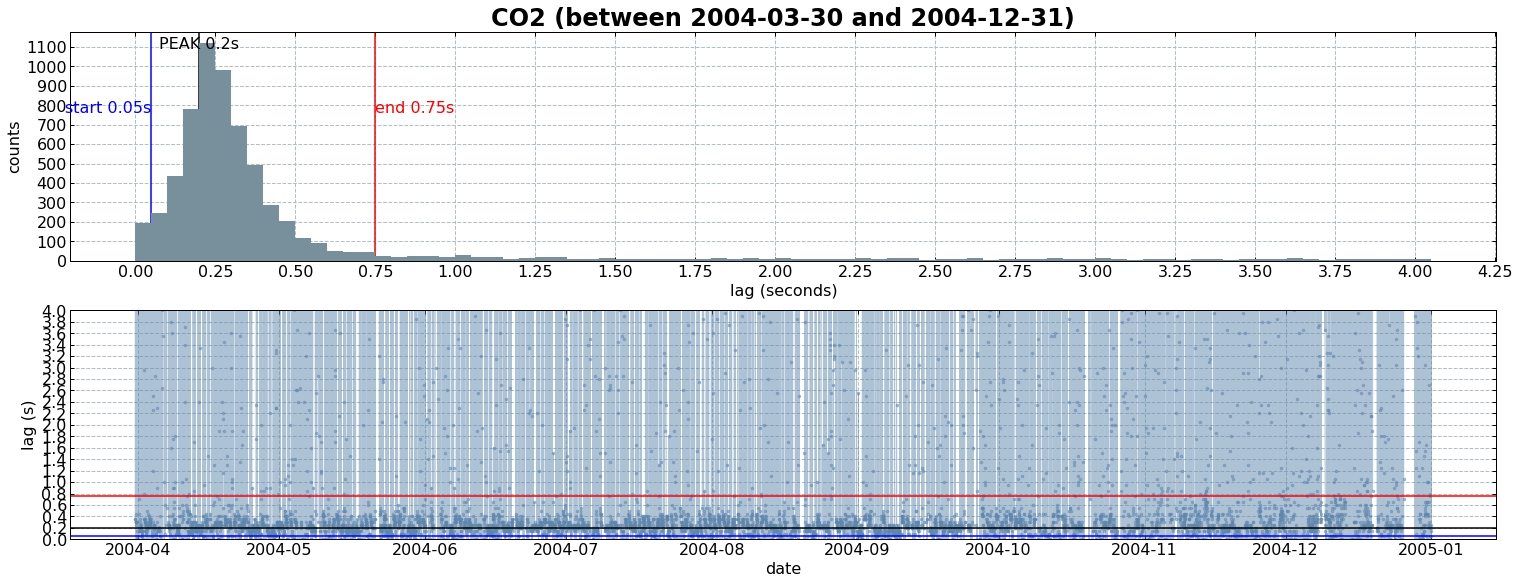

In [17]:
timelags(gascol="CO2", series=tlag_actual["CO2_TLAG_ACTUAL"], vline1=0.05, vline2=0.75, startbin=0, endbin=4)

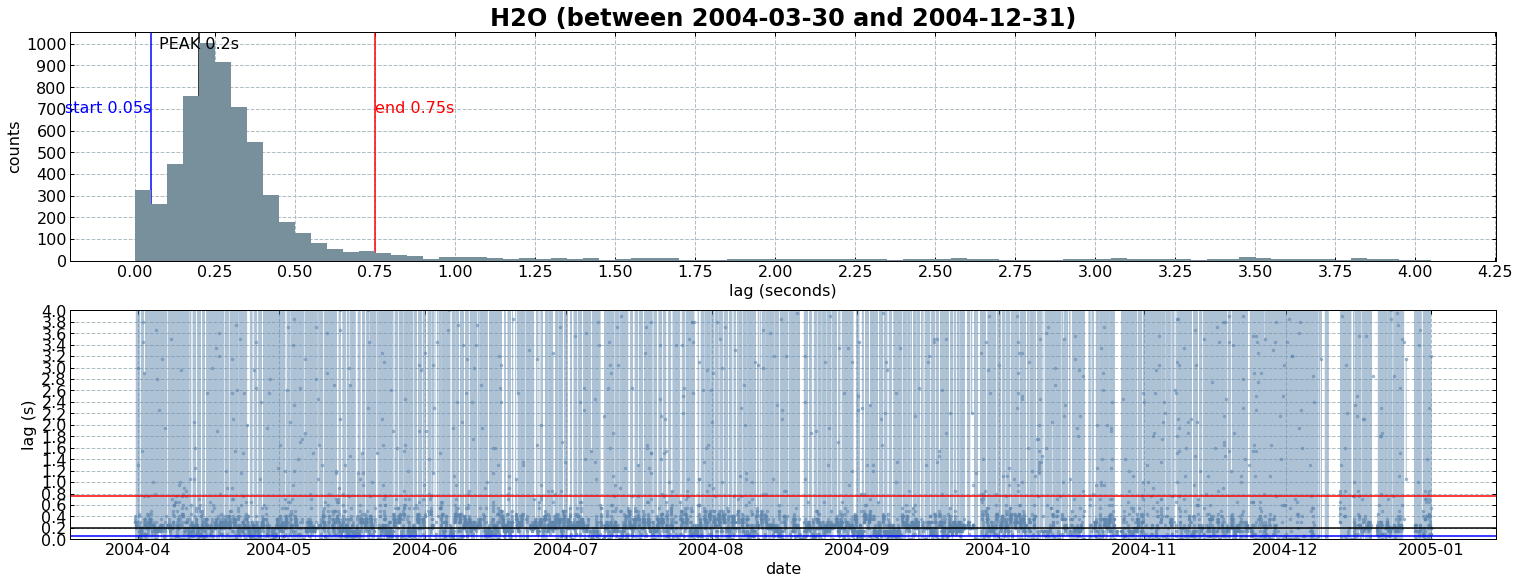

In [18]:
timelags(gascol="H2O", series=tlag_actual["H2O_TLAG_ACTUAL"], vline1=0.05, vline2=0.75, startbin=0, endbin=4)

## 2005_1+4

In [23]:
locs = ((df.index > "2004-12-31 23:00:00") & (df.index <= "2005-09-30 10:48:00")) | ((df.index > "2005-11-12 15:55:00") & (df.index <= "2005-12-30 23:00:00"))
tlag_actual = df[tlag_actual_cols][locs].copy()
first_date = tlag_actual.index[0].date()
last_date = tlag_actual.index[-1].date()

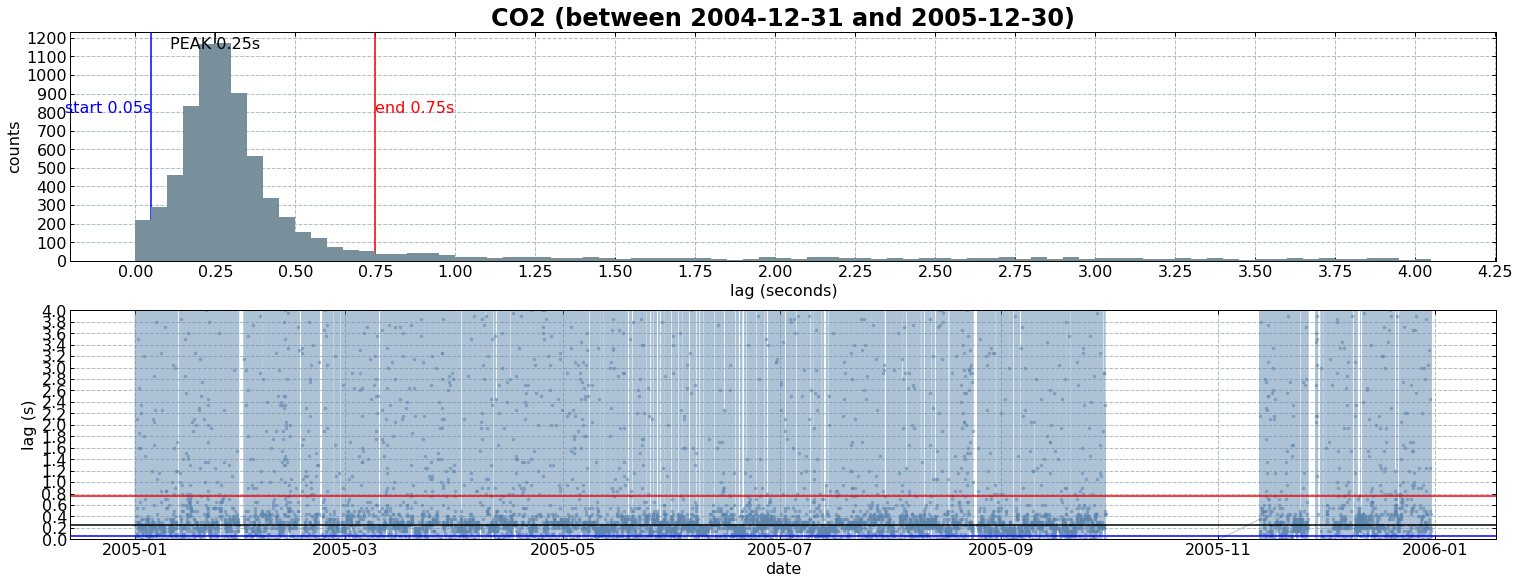

In [24]:
timelags(gascol="CO2", series=tlag_actual["CO2_TLAG_ACTUAL"], vline1=0.05, vline2=0.75, startbin=0, endbin=4)

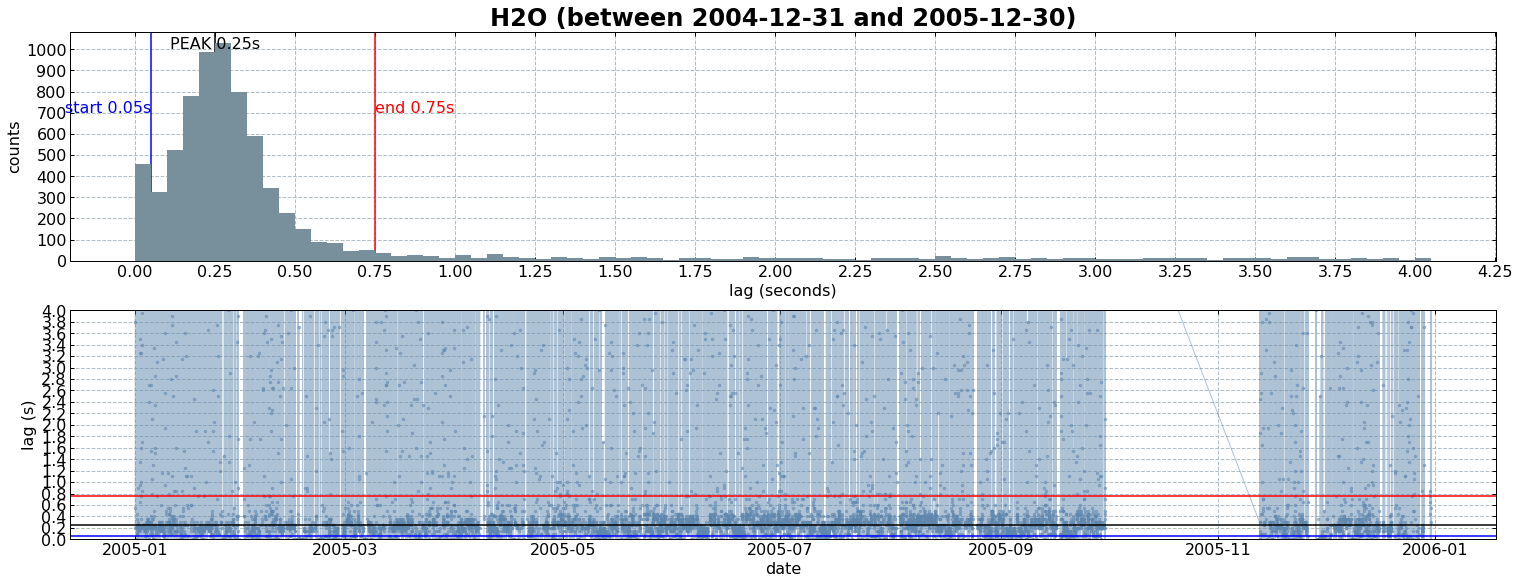

In [25]:
timelags(gascol="H2O", series=tlag_actual["H2O_TLAG_ACTUAL"], vline1=0.05, vline2=0.75, startbin=0, endbin=4)

# End of notebook.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")